# 同一个节点调用多个子图时
#### 需要注意多次调用子图的顺序不能变，因为checkpoints 时通过顺序来记录记忆的
#### 更好的方式时每个节点只调用一个子图
`fruit_response = fruit_subgraph.invoke({"messages": fruit_messages})
 vegetable_response = vegetable_subgraph.invoke({"messages": vegetable_messages})`


2026-08-08 09:33:25.334 | INFO     | __main__:fruit_node:33 - ==============================
2026-08-08 09:33:25.335 | INFO     | __main__:fruit_node:34 - 调用水果子图的 fruit_node 节点，当前的 messages: 
2026-08-08 09:33:25.336 | INFO     | __main__:fruit_node:36 - 
[消息 1]
类型：system
内容：用最简短的话介绍用户输入的水果
2026-08-08 09:33:25.336 | INFO     | __main__:fruit_node:36 - 
[消息 2]
类型：human
内容：桑葚
2026-08-08 09:33:25.337 | INFO     | __main__:fruit_node:44 - ==============================
2026-08-08 09:33:26.787 | INFO     | __main__:vegetable_node:62 - ==============================
2026-08-08 09:33:26.787 | INFO     | __main__:vegetable_node:63 - 调用蔬菜子图的 vegetable_node 节点，当前的 messages: 
2026-08-08 09:33:26.787 | INFO     | __main__:vegetable_node:65 - 
[消息 1]
类型：system
内容：用最简短的话介绍用户输入的蔬菜
2026-08-08 09:33:26.788 | INFO     | __main__:vegetable_node:65 - 
[消息 2]
类型：human
内容：西兰苔
2026-08-08 09:33:26.788 | INFO     | __main__:vegetable_node:73 - ==============================
============================== -> 第一次

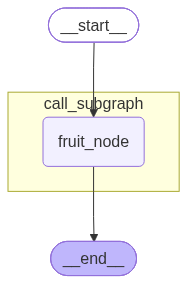

In [1]:
import sys
from typing import TypedDict

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END, MessagesState
from loguru import logger

logger.remove()
logger.add(sys.stdout, colorize=True)

from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# ==================================================
# 【策略切换点】两个子图的编译参数
# ==================================================

# 构建水果子图
def fruit_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用水果子图的 fruit_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }


builder = StateGraph(state_schema=MessagesState)
builder.add_node("fruit_node", fruit_node)
builder.add_edge(START, "fruit_node")
builder.add_edge("fruit_node", END)

fruit_subgraph = builder.compile(checkpointer=True)


# 构建蔬菜子图
def vegetable_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用蔬菜子图的 vegetable_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }


builder = StateGraph(state_schema=MessagesState)
builder.add_node("vegetable_node", vegetable_node)
builder.add_edge(START, "vegetable_node")
builder.add_edge("vegetable_node", END)

vegetable_subgraph = builder.compile(checkpointer=True)


# 构建父图
class OverAllState(TypedDict):
    fruit: str  # 水果
    vegetable: str  # 蔬菜

    fruit_introduction: str  # 水果介绍
    vegetable_introduction: str  # 蔬菜介绍


def call_subgraph(state: OverAllState) -> OverAllState:
    fruit = state["fruit"]
    vegetable = state["vegetable"]

    fruit_messages = [
        SystemMessage("用最简短的话介绍用户输入的水果"),
        HumanMessage(fruit)
    ]

    vegetable_messages = [
        SystemMessage("用最简短的话介绍用户输入的蔬菜"),
        HumanMessage(vegetable)
    ]

    fruit_response = fruit_subgraph.invoke({"messages": fruit_messages})
    vegetable_response = vegetable_subgraph.invoke({"messages": vegetable_messages})

    fruit_introduction = fruit_response["messages"][-1].content
    vegetable_introduction = vegetable_response["messages"][-1].content

    return {
        "fruit_introduction": fruit_introduction,
        "vegetable_introduction": vegetable_introduction
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "multi-call-diff-demo"}}

first_response = parent_graph.invoke(
    {
        "fruit": "桑葚",
        "vegetable": "西兰苔"
    },
    config=config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "fruit": "香蕉",
        "vegetable": "西兰花"
    },
    config=config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image

display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)